In [22]:
import gamry_parser
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
from pathlib import Path
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import make_splrep
import math
from scipy.signal import savgol_filter

main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\EIS_data")
file_list = list(main_dir.rglob('*_48H.DTA'))

all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    data = parser.curves[0]
    eis_data = {
        'name':str(filename).split("\\")[-1],
        'Zreal':data['Zreal'].values,
        'Zimag':-data['Zimag'].values,
        'Zmod':data['Zmod'].values,
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values
    }
    if float(((str(filename).split("\\")[-1]).split('_')[-1]).replace("H.DTA","")) < 24:
        k = 1
        K = 7
    else:
        k = 0.2
        K = 5
    
    w = np.ones(len(data['Freq'].values))
    w[data['Freq'].values < k] = 0.5
    w[data['Freq'].values > k] = 10
    
    sigma_auto = np.std(np.diff(data['Zphz'].values[data['Freq'].values < 0.1]))
    s = math.ceil(sigma_auto/10*len(data['Freq'].values))
                                              
    sigma_auto1 = np.std(np.diff(data['Zreal'].values[data['Freq'].values < 0.1]))/np.mean(data['Zmod'].values[data['Freq'].values < 0.1])
    s1 = sigma_auto1*len(data['Freq'].values)
    
    sigma_auto2 = np.std(np.diff(data['Zimag'].values[data['Freq'].values < 0.1]))/np.mean(data['Zmod'].values[data['Freq'].values < 0.1])
    s2 = (sigma_auto2*len(data['Freq'].values))
    
    #y_smooth = savgol_filter(y, window_length=11, polyorder=3)
    
    #spl_Zreal = make_splrep(np.log10(np.flip(data['Freq'].values)), savgol_filter(np.flip(data['Zreal'].values),window_length=11, polyorder=3) ,w = np.flip(w),s = (sigma_auto1*K*np.mean(data['Zmod'].values))**2)
    #spl_Zimag = make_splrep(np.log10(np.flip(data['Freq'].values)), savgol_filter(np.flip(data['Zimag'].values),window_length=11, polyorder=3),w  = np.flip(w),s = (sigma_auto2*K*np.mean(data['Zmod'].values))**2)
    spl_Zmod = make_splrep(np.log10(np.flip(data['Freq'].values)), np.log10(np.flip(data['Zmod'].values)),w= np.flip(w),s = s/1e4)
    spl_Zphz = make_splrep(np.flip(data['Freq'].values), np.flip(data['Zphz'].values),w =np.flip(w),s = s)

    a = np.log10(np.flip(data['Freq'].values))
    eis_data_filtered = {
        'name':str(filename).split("\\")[-1],
        #'Zreal':spl_Zreal(np.log10(np.flip(data['Freq'].values))),
        #'Zimag':-spl_Zimag(np.log10(np.flip(data['Freq'].values))),
        'Zreal':savgol_filter(np.flip(data['Zreal'].values),window_length=11, polyorder=3),
        'Zimag':-savgol_filter(np.flip(data['Zimag'].values),window_length=11, polyorder=3),
        'Zmod':spl_Zmod(np.log10(np.flip(data['Freq'].values))),
        'Zphz':spl_Zphz(np.flip(data['Freq'].values)),
        'Freq':np.flip(data['Freq'].values)
    }
    
    all_datasets.append({"eis_data":eis_data,"eis_data_filtered":eis_data_filtered})
    print(eis_data['name'])


Cauvel_2_8HQ_48H.DTA
Cauvel_3_BTA_48H.DTA
Cauvel_1_Lcystine_48H.DTA
Cauvel_1_MBT_48H.DTA
Cauvel_3_Mo_48H.DTA
Cauvel_4_NaCl_48H.DTA
Cauvel_2_NaVO3_48H.DTA
Cauvel_4_NaVO3_48H.DTA


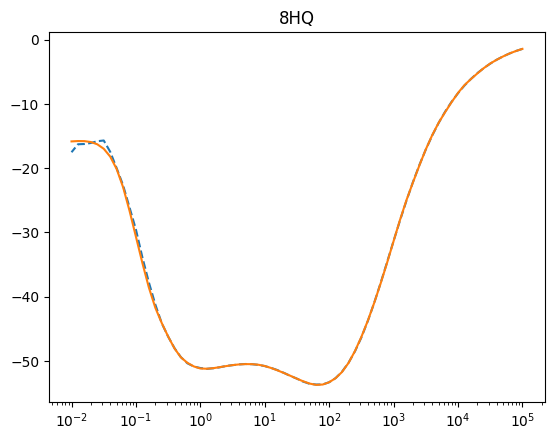

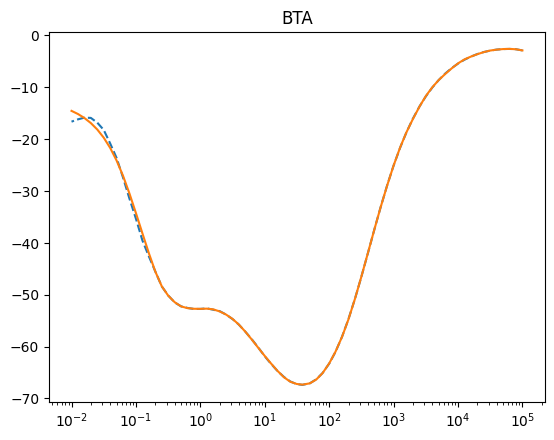

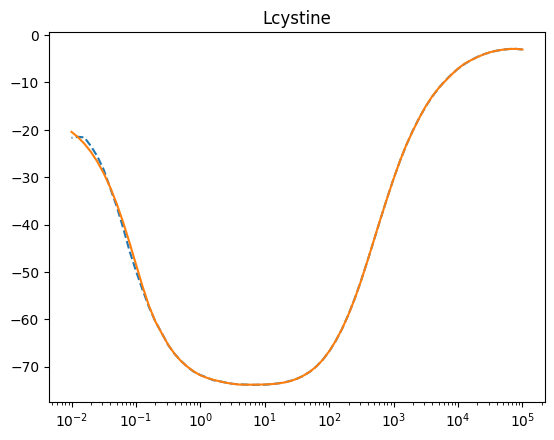

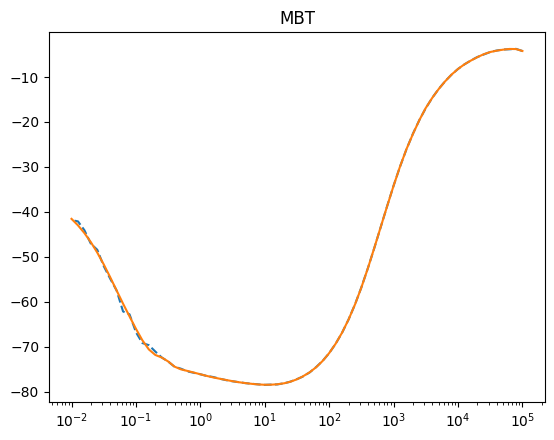

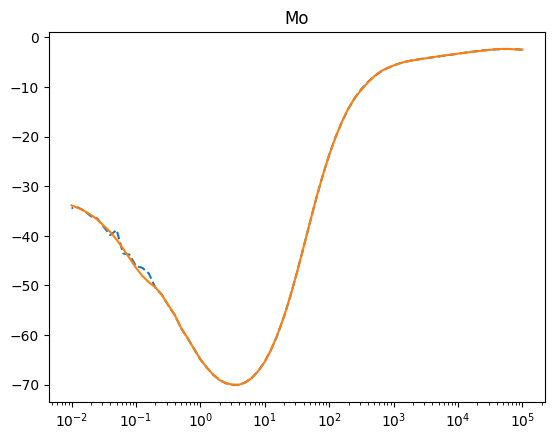

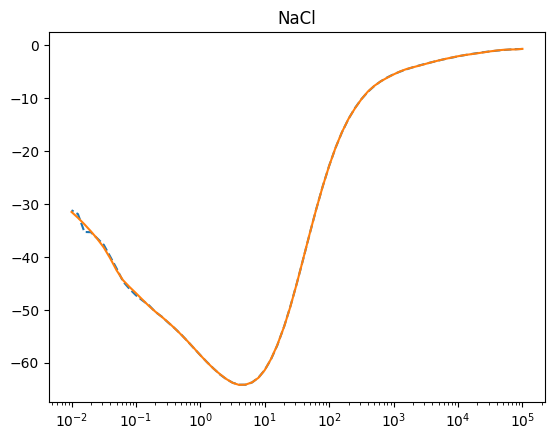

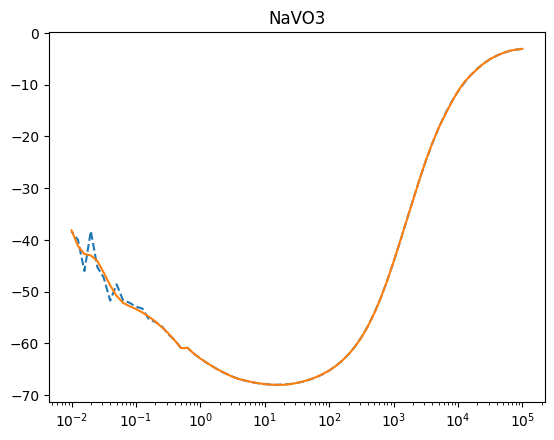

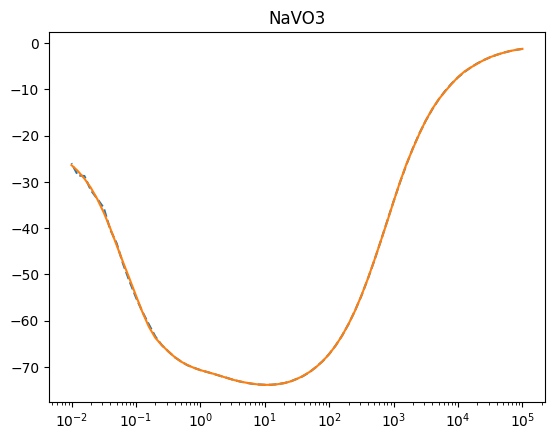

In [23]:
for i, dataset in enumerate(all_datasets):
    plt.semilogx(dataset['eis_data']['Freq'],dataset['eis_data']['Zphz'], '--')
    plt.semilogx(dataset['eis_data_filtered']['Freq'], dataset['eis_data_filtered']['Zphz'])
    plt.title(dataset['eis_data_filtered']['name'].split('_')[2])
    plt.show()

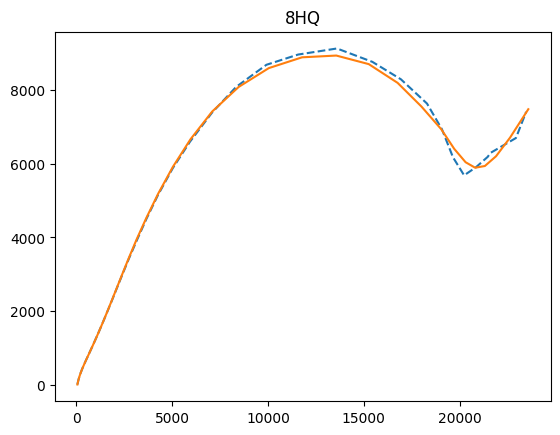

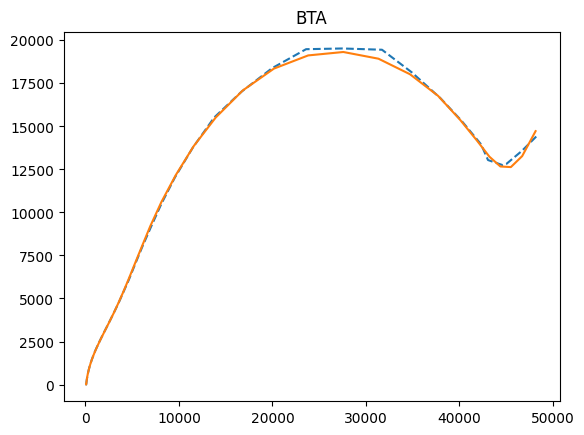

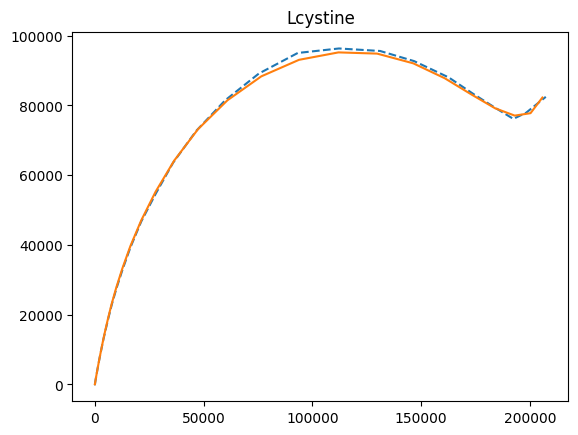

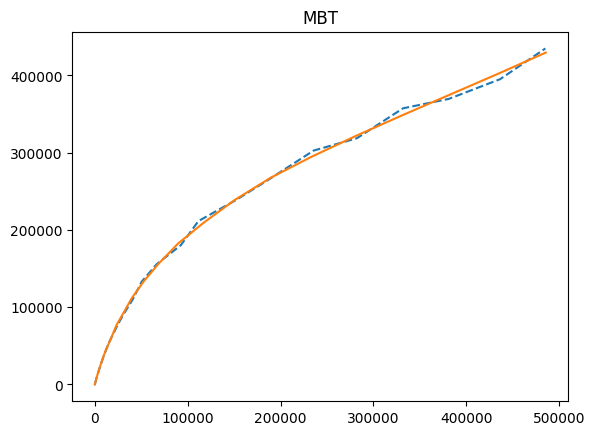

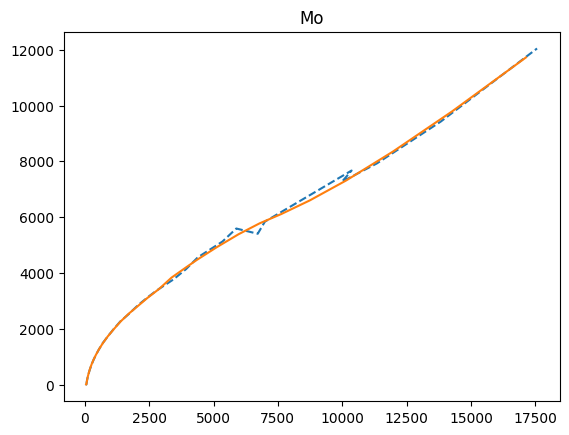

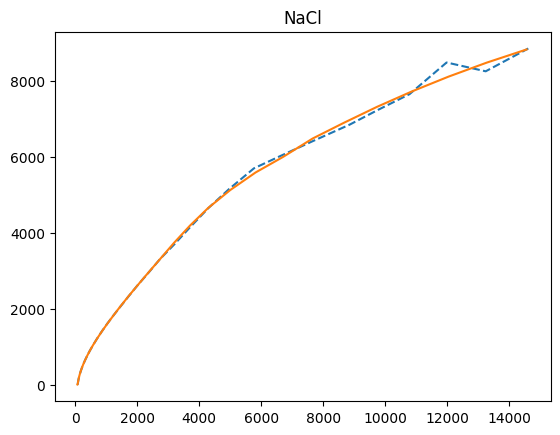

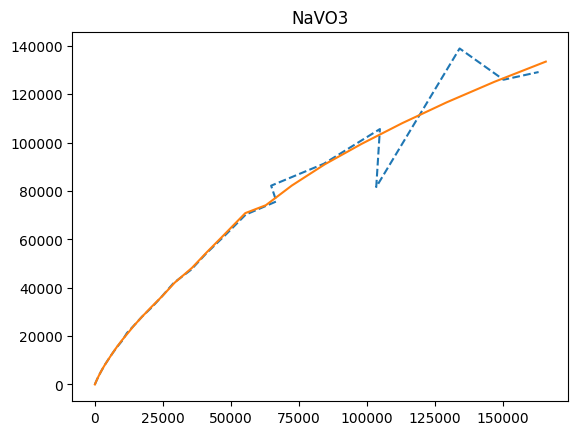

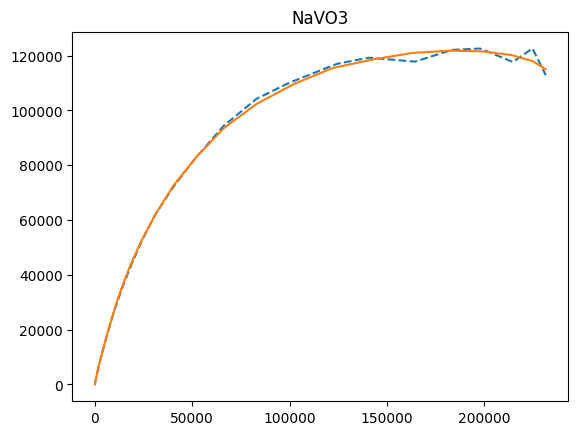

In [24]:
for i, dataset in enumerate(all_datasets):
    plt.plot(dataset['eis_data']['Zreal'],dataset['eis_data']['Zimag'],'--')
    plt.plot(dataset['eis_data_filtered']['Zreal'], dataset['eis_data_filtered']['Zimag'],)
    plt.title(dataset['eis_data_filtered']['name'].split('_')[2])
    plt.show()